# Movie Recommendation System using NMF(Non-Negative Matrix Factorization), and using TF-IDF Vectorizer

## Importing the necessary requirements (Libraries & Dataset)

In [10]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

In [11]:
# Downloading our dataset - TMDB dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tmdb-movies-dataset-2023-930k-movies' dataset.
Path to dataset files: /kaggle/input/tmdb-movies-dataset-2023-930k-movies


## Data processing

In [12]:
# Reading our .csv data into a dataframe
df = pd.read_csv("/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv")

print(f"Samples in the data: {df.shape[0]}")
print(f"Features in the data: {df.shape[1]}")
print("Column Names:")
print(df.isnull().sum())

Samples in the data: 1421440
Features in the data: 24
Column Names:
id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             316821
revenue                       0
runtime                       0
adult                         0
backdrop_path           1068588
budget                        0
homepage                1275387
imdb_id                  752842
original_language             0
original_title               18
overview                 326301
popularity                    0
poster_path              505666
tagline                 1223429
genres                   625152
production_companies     816694
production_countries     688383
spoken_languages         660992
keywords                1070239
dtype: int64


In [13]:
# Selecting the features of our data relevant for our use (title,overview,genres)

df = df[["title","overview","genres"]].dropna()

print("The new stats of our data are")
print("="*30)
print(f"Samples in the data: {df.shape[0]}")
print(f"Features in the data: {df.shape[1]}")
print("Column Names:")
print(df.isnull().sum())

The new stats of our data are
Samples in the data: 651045
Features in the data: 3
Column Names:
title       0
overview    0
genres      0
dtype: int64


In [14]:
# Viewing the first three rows of our data
df.head(3)

,title,overview,genres
0,Inception,"Cobb, a skilled thief who commits corporate es...","Action, Science Fiction, Adventure"
1,Interstellar,The adventures of a group of explorers who mak...,"Adventure, Drama, Science Fiction"
2,The Dark Knight,Batman raises the stakes in his war on crime. ...,"Drama, Action, Crime, Thriller"


## Making our TF-IDF matrix from the "overview" feature and building our NMF model


In [15]:
# Making our TF-IDF matrix

tfidf = TfidfVectorizer(
    max_features = 5000,  # Take the 5000 most important words as features
    stop_words = "english", # Words such as 'as','the', 'a' etc are not taken into account
    ngram_range=(1,2), # Include both unigrams and two-word phrases(bigrams) such as 'serial killer', 'outer space' as single features  rather than picking them up as noise
    min_df = 2 # A word must be appear in atleast 2 movies to be included, So that typos and ultra-rare words are excluded.
)

X = tfidf.fit_transform(df["overview"])

print("Matrix shape: ",X.shape)
print("Type: ",type(X))
print("Non-zero entries: ", X.nnz)
print(f"Sparsity: {100* (1-X.nnz/(X.shape[0]*X.shape[1])):.1f}% zeros.")

Matrix shape:  (651045, 5000)
Type:  <class 'scipy.sparse._csr.csr_matrix'>
Non-zero entries:  11126275
Sparsity: 99.7% zeros.


### The ouput of the cell above represents
* (n_movies,n_words) -> (651045,5000)
* X.nnz → number of stored (non-zero) values. Tells you how dense the data is.
* Sparsity → expect 95-99% zeros. This is totally normal for text data.

In [19]:
# Saving our tfidf_matrix
import os
from pathlib import Path
from scipy.sparse import save_npz

os.makedirs(os.path.dirname("data/tfidf_matrix.npz"),exist_ok = True)
save_npz("data/tfidf_matrix.npz",X)

In [20]:
# Exploring the Vocabulary

vocab = tfidf.get_feature_names_out()

# Q1: How many unique words/phrases did TF-IDF learn?
print("Vocabulary size:", len(vocab))

# Q2: Show the first 20 features
print("First 20 features:", vocab[:20])

# Q3: Convert one movie's TF-IDF row to a readable Series and show top 10 words
movie_idx = 0   # ← change this to try different movies
movie_vec = pd.Series(
    X[movie_idx].toarray().flatten(),
    index=vocab
).sort_values(ascending=False)

print(f"\nTop 10 TF-IDF words for '{df['title'].iloc[movie_idx]}':")
print(movie_vec.head(10))

Vocabulary size: 5000
First 20 features: ['000' '01' '02' '03' '04' '05' '06' '07' '08' '10' '10 year' '10 years'
 '100' '10th' '11' '12' '12 year' '13' '14' '15']

Top 10 TF-IDF words for 'Inception':
commits       0.318179
regain        0.314887
corporate     0.309724
offered       0.303739
target        0.291715
task          0.280963
impossible    0.280728
thief         0.280707
considered    0.280601
idea          0.254531
dtype: float64


In [21]:
# Now building our NMF model

# Selecting the number of topics to be 20
K = 20

nmf_model = NMF(
    n_components = K,
    init = "nndsvda",# the initialisation strategy. nndsvda uses SVD to make an intelligent first guess at W and H, which leads to faster convergence and better results than random initialisation. This is the recommended setting for sparse TF-IDF data.
    random_state = 42,
    max_iter = 400
)

W =  nmf_model.fit_transform(X)  # movies * topics
H =  nmf_model.components_  # topics * words

print("W shape (movies × topics):", W.shape)
print("H shape (topics × words) :", H.shape)
print(f"Reconstruction error     : {nmf_model.reconstruction_err_:.4f}") # how well W × H approximates X. Lower is better. It's the Frobenius norm of X - W×H

W shape (movies × topics): (651045, 20)
H shape (topics × words) : (20, 5000)
Reconstruction error     : 783.7019


In [22]:
# Inspecting the topics
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic_vec in enumerate(model.components_):
        top_word_indices = topic_vec.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_word_indices]
        print(f"Topic {topic_idx:2d}: {' | '.join(top_words)}")

vocab = tfidf.get_feature_names_out()
print_topics(nmf_model, vocab)

Topic  0: time | friends | day | people | night | town | way | lives | group | friend
Topic  1: film | documentary film | director | horror film | feature | horror | feature film | film directed | based | animated film
Topic  2: short film | short | film | animated short | experimental | animated | documentary short | film directed | inspired | film based
Topic  3: short | animated | short documentary | animation | horror | animated short | animated film | short story | horror film | experimental
Topic  4: documentary | documentary film | short documentary | making | history | documentary making | interviews | documentary short | people | filmmaker
Topic  5: love | story | falls | falls love | tells | love story | tells story | based | true | fall
Topic  6: old | year | year old | boy | years | old boy | old girl | old man | years old | 12
Topic  7: life | death | work | day | daily | day life | everyday | real life | real | career
Topic  8: man | young man | wife | old man | finds | t

## Using the model to make Recommendations- through cosine similarity

The logic
We have W of shape (movies × topics). Each row is a movie's "topic fingerprint" — a vector describing how much of each topic it contains.
To recommend movies similar to a query movie, we:

1. Look up its row in W.
2. Compute how similar that row is to every other row.
3. Return the movies with highest similarity.

We use **cosine similarity** — it measures the angle between two vectors, not their magnitude. This is better than Euclidean distance for text because it's scale-invariant (a long detailed plot vs a short plot won't be penalised for length).
cosine_similarity(A, B) = (A · B) / (||A|| × ||B||)
If we first normalise every row of W to unit length (||row|| = 1), then cosine similarity = dot product, which is faster.

` cosine_similarity(A, B) = (A · B) / (||A|| × ||B||) `

In [24]:
# Making the predictions and thus recommendations

# First we normalize every row of W using L2 norm
W_norm = normalize(W,norm="l2")

# The recommendation function
def recommend(query_title,df,W_norm,top_n = 5):

  # 1.) Find the row index of the query movie in the original dataframe
  matches = df.index[df["title"] == query_title].tolist()

  if not matches:
    print(f"Movie '{query_title}' not found..")
    return

  idx = matches[0]

  # now we compute the cosine similarity of query movie vs all other movies
  query_vec = W_norm[idx].reshape(1,-1)
  sims = cosine_similarity(query_vec,W_norm)[0]

  # Sort similarity in the descending order, skipping the index 0 cause it is the queried movie itself
  ranked = np.argsort(sims)[::-1]
  ranked = [i for i in ranked if i!= idx][:top_n]

  print(f"\n Because you watched: '{query_title}'")
  print(f"   Genre: {df.loc[idx, 'genre'] if 'genre' in df.columns else 'unknown'}")
  print(f"{'─'*50}")
  for rank, movie_idx in enumerate(ranked, 1):
    title  = df["title"].iloc[movie_idx]
    genre  = df["genre"].iloc[movie_idx] if "genre" in df.columns else ""
    score  = sims[movie_idx]
    print(f"  {rank}. {title:<35} sim={score:.3f}  [{genre}]")

# Test it
recommend("Inception", df, W_norm)
recommend("The Godfather", df, W_norm)
recommend("Amélie", df, W_norm)


 Because you watched: 'Inception'
   Genre: unknown
──────────────────────────────────────────────────
  1. AGOS-TONO                           sim=1.000  []
  2. Fax                                 sim=1.000  []
  3. Blossom                             sim=1.000  []
  4. Life as it Comes - Scenes from a Hungarian Town in an Election Year sim=1.000  []
  5. Magokoro                            sim=1.000  []

 Because you watched: 'The Godfather'
   Genre: unknown
──────────────────────────────────────────────────
  1. Pyar Ka Mandir                      sim=0.997  []
  2. Ahasaas                             sim=0.997  []
  3. Three-Cornered Moon                 sim=0.996  []
  4. Pájaros negros                      sim=0.996  []
  5. The American Standards              sim=0.996  []

 Because you watched: 'Amélie'
   Genre: unknown
──────────────────────────────────────────────────
  1. Junoon e Ishq                       sim=0.999  []
  2. All Things Valentine                sim=0.999

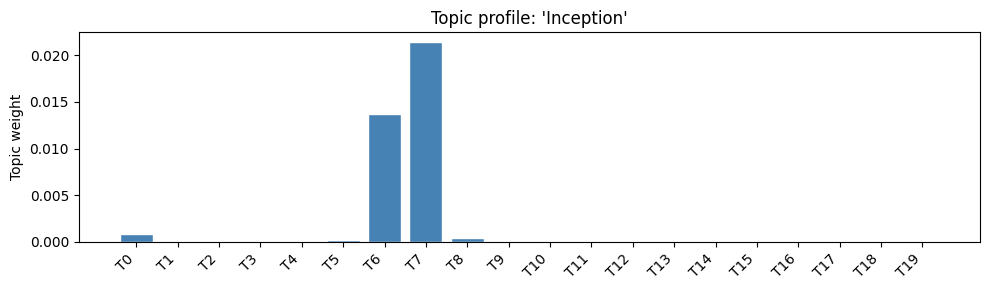

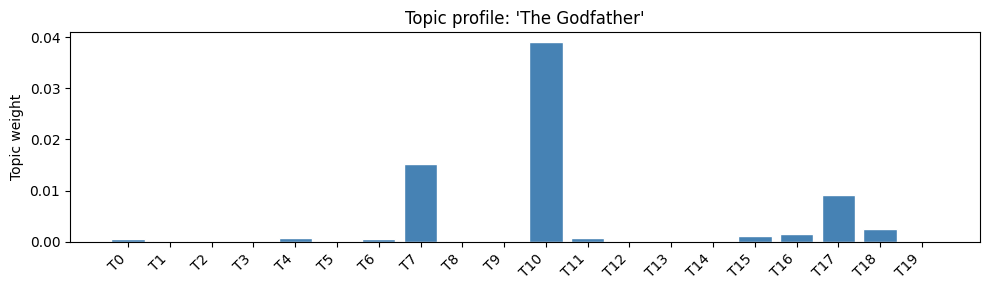

In [25]:
# Visualizing the movie's topic fingerprint
def plot_topic_profile(query_title, df, W, topic_labels=None):
    idx = df.index[df["title"] == query_title][0]
    profile = W[idx]
    labels  = topic_labels if topic_labels else [f"T{i}" for i in range(len(profile))]

    plt.figure(figsize=(10, 3))
    bars = plt.bar(labels, profile, color="steelblue", edgecolor="white")
    plt.title(f"Topic profile: '{query_title}'")
    plt.ylabel("Topic weight")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Example (replace labels with your own from Exercise 2)
plot_topic_profile("Inception", df, W)
plot_topic_profile("The Godfather", df, W)